<a href="https://colab.research.google.com/github/HST0077/HYOTC/blob/main/LDA%26Zscore.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Linear Discriminant Analysis**

In [ ]:
# 분석 데이터 만들기

from sklearn.datasets import make_classification
import pandas as pd

# make_classification:
# - 분류 문제용 가상 데이터(특징 행렬 X, 라벨 y)를 생성해주는 유틸리티
# - n_features: 전체 변수 개수
# - n_informative: 분류에 실제로 유용한 변수 개수
# - n_redundant: 유용한 변수를 조합해 만든 중복 변수 개수
# - class_sep: 클래스(0/1)가 얼마나 잘 분리되는지(클수록 쉬운 문제)

X, y = make_classification(
    n_samples=1500,     # 샘플 수(관측치 개수)
    n_features=10,      # 독립변수 개수
    n_informative=5,    # 분류에 핵심적으로 기여하는 변수 수
    n_redundant=2,      # 다른 변수들의 선형결합으로 만들어진 중복 변수 수
    class_sep=1.2,      # 클래스 분리 정도(크면 분류가 쉬움)
    random_state=42     # 재현 가능하도록 시드 고정
)

# Create DataFrame for display
feature_names = [f"x{i+1}" for i in range(X.shape[1])]
df= pd.DataFrame(X, columns=feature_names)
df["y"] = y
df.head()

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,y
0,0.217557,-0.289866,-1.889714,-0.563298,1.638655,0.423646,-0.771617,2.544470,0.129684,-1.687705,1
1,0.730332,1.493923,-0.978125,-1.674227,0.856431,-0.030041,1.593623,-1.775807,1.685816,0.163634,1
2,-3.471090,0.831200,1.301524,0.640171,-1.444864,-0.020427,-0.072655,1.503097,-1.608630,-1.171414,0
3,2.772002,0.317200,-1.421187,-0.171758,0.857611,-1.026694,0.646694,-1.316131,3.746071,0.043762,1
4,-3.368208,1.747925,0.024881,0.930875,-0.473196,0.976374,-0.045946,1.794067,-0.875212,-0.985810,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      1500 non-null   float64
 1   x2      1500 non-null   float64
 2   x3      1500 non-null   float64
 3   x4      1500 non-null   float64
 4   x5      1500 non-null   float64
 5   x6      1500 non-null   float64
 6   x7      1500 non-null   float64
 7   x8      1500 non-null   float64
 8   x9      1500 non-null   float64
 9   x10     1500 non-null   float64
 10  y       1500 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 129.0 KB


In [ ]:
df["y"].value_counts()

,count
y,
1,754
0,746


In [ ]:
# ============================================================
# Train / Test 데이터 분리
# ============================================================
from sklearn.model_selection import train_test_split

# - 모델은 train 데이터로 학습하고, test 데이터로 "처음 보는 데이터"에서 성능을 평가한다.
# - stratify=y: train/test에서 클래스 비율(0/1 비율)을 동일하게 유지
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,     # 전체의 25%를 테스트용으로 사용
    random_state=42,
    stratify=y
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1125, 10), (375, 10), (1125,), (375,))

In [ ]:
# LDA

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score,confusion_matrix

model=LinearDiscriminantAnalysis()
model.fit(X_train, y_train) # 모델 학습
y_pred = model.predict(X_test) # 모델 예측

# 정확도(맞춘 비율)
print("Accuracy:", accuracy_score(y_test, y_pred))

# 혼동행렬(confusion matrix)
# - [[TN, FP],
#    [FN, TP]]
print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred, labels=[0,1]))

Accuracy: 0.896

Confusion matrix:
 [[168  19]
 [ 20 168]]


In [ ]:
# 회귀식 출력하기
feature_names = [f"x{i+1}" for i in range(X_train.shape[1])]
w = model.coef_.ravel()
b = float(model.intercept_.ravel()[0])

expr = " + ".join([f"({w[i]:.6f})*{feature_names[i]}" for i in range(len(w))])
print("Score(x) = ", expr, f" + ({b:.6f})")

Score(x) =  (0.360994)*x1 + (-1.250829)*x2 + (0.143419)*x3 + (0.024158)*x4 + (0.821138)*x5 + (0.120841)*x6 + (1.528439)*x7 + (-0.800567)*x8 + (-1.066619)*x9 + (0.023725)*x10  + (1.855836)


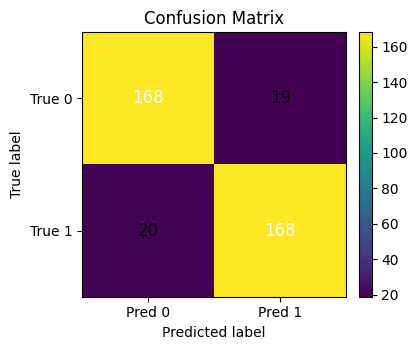

In [ ]:
# 혼동행렬 시각화 출력
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 혼동행렬 계산
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

# 보기 좋게 시각화 (matplotlib)
fig, ax = plt.subplots(figsize=(4.2, 3.6))
im = ax.imshow(cm)  # 색상은 matplotlib 기본 colormap 사용

# 축/라벨
ax.set_xticks([0, 1], labels=["Pred 0", "Pred 1"])
ax.set_yticks([0, 1], labels=["True 0", "True 1"])
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_title("Confusion Matrix")

# 셀 안에 숫자 표시
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i, f"{cm[i, j]}",
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black",
            fontsize=12
        )

# 컬러바
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

# **(Altman’s Z score) 다음과 같은 재무정보를 가진 회사의 Z score를 산출하고 부도위험이 있는지 판별하여라. 운전자본은 170,000이고, 총자산은 670,000이며, 이자 및 법인세 차감 전 이익(EBIT)은 60,000이다. 매출액은 2,200,000이고, 자기자본의 시장가치는 380,000이며, 총부채는 240,000이고, 이익잉여금은 300,000이다**

In [ ]:
X1=170000/670000
X1

0.2537313432835821

In [ ]:
X2=300000/670000
X2

0.44776119402985076

In [ ]:
X3=60000/670000
X3

0.08955223880597014

In [ ]:
X4=380000/240000
X4

1.5833333333333333

In [ ]:
X5=2200000/670000
X5

3.283582089552239

In [ ]:
def altman_z_score(working_capital: float,
                   total_assets: float,
                   retained_earnings: float,
                   ebit: float,
                   market_value_equity: float,
                   total_liabilities: float,
                   sales: float) -> float:

    x1 = working_capital / total_assets
    x2 = retained_earnings / total_assets
    x3 = ebit / total_assets
    x4 = market_value_equity / total_liabilities
    x5 = sales / total_assets
    print(x1,x2,x3,x4,x5)

    return 1.2 * x1 + 1.4 * x2 + 3.3 * x3 + 0.6 * x4 + 0.999 * x5


In [ ]:
altman_z_score(170000,670000,300000,60000,380000,240000,2200000)

0.2537313432835821 0.44776119402985076 0.08955223880597014 1.5833333333333333 3.283582089552239


5.457164179104478

In [ ]:
def altman_z_score_1(x1,x2,x3,x4,x5):

    return 1.2 * x1 + 1.4 * x2 + 3.3 * x3 + 0.6 * x4 + 0.999 * x5

In [ ]:
altman_z_score_1(X1,X2,X3,X4,X5)

5.457164179104478